# Ablación de features: qué aporta, qué se borra

Este notebook mide, con el mismo protocolo, **cada bloque de columnas** que el pipeline fue
agregando, y decide qué sobrevive. La regla es una: lo que no aporta se borra del pipeline,
con el número que lo condenó anotado. Tiene dos partes porque el pipeline tuvo dos momentos.

## Protocolo, y por qué es así

- **Un modelo por operación.** Canon mensual y precio de venta no comparten escala.
- **Target `log(precio)`**, error reportado como MAE en log (≈ error relativo) y MdAPE.
- **Split agrupado, siempre.** El 9 % de las filas son near-duplicados (mismo proyecto
  republicado): con split aleatorio la unidad 3 queda en train y la 7 en test, el modelo ya
  vio la respuesta y la métrica miente.
- **Dos regímenes.** `conocido` agrupa por near-duplicado (barrios ya vistos en train);
  `frio` agrupa por sector entero, así que el modelo tiene que valuar barrios que nunca vio.
  El segundo es el que se parece a producción.
- **Cada bloque se mide acumulado y aislado**, para separar lo que aporta de lo que es
  redundante con otro bloque.


---

# Parte A — El respaldo OpenStreetMap + Esri (historia, ya borrado)

Antes de que existiera `src/detail.py`, la única ubicación disponible era el string
`sector`. La primera versión de `src/enrich.py` lo resolvía contra un gazetteer de barrios de
OpenStreetMap (Overpass + Nominatim, 15 ciudades, bbox por mosaicos) y consultaba el estrato
predominante por manzana en el servicio de Esri Colombia (envelope de 400 m, moda). Llegó a
**47,4 % de cobertura** en las 15 ciudades y a 40,4 % global; el cuello era que la mitad de
los sectores no existen en OSM con el nombre que usan los anunciantes.

Esa versión se midió con este mismo protocolo, sobre las filas con match, y estos son los
números que quedaron. Las celdas de código de esta parte **ya no existen** porque sus columnas
(`lat_barrio`, `estrato_modal`...) ya no se producen; el código está en el historial de git
(commits `cb50b1f` a `0beca8e`).

### A.1 Compuerta del respaldo (filas con match, 15 ciudades)

| bloque agregado | arriendo conocido | arriendo **frío** | venta conocido | venta **frío** |
|---|---|---|---|---|
| baseline (tarjeta) | 0,844 | 0,822 | 0,871 | 0,827 |
| + coordenada del barrio | **0,876** (+0,032) | **0,832** (+0,010) | **0,901** (+0,030) | **0,866** (+0,039) |
| + estrato modal | 0,879 (+0,002) | 0,823 (+0,001) | 0,903 (+0,001) | 0,847 (+0,001) |

Pasó la compuerta del EDA (0,833 / 0,860) y justificó cargar la data al lakehouse.


Estos bloques **ya no existen** en `anuncios_enriquecido.parquet`: los produjo una versión
anterior de `src/enrich.py` y se quitaron tras esta medición. Las cifras quedan acá para
que nadie los reintroduzca sin volver a medirlos, y el código sigue disponible en el
historial de git.

### A.2 Lo que se probó y se borró en aquel momento

Ablación acumulativa sobre las 15 ciudades:

| bloque agregado | arriendo conocido | arriendo **frío** | venta conocido | venta **frío** |
|---|---|---|---|---|
| baseline | 0,844 | 0,822 | 0,871 | 0,827 |
| + coordenadas | **0,876** (+0,032) | **0,832** (+0,010) | **0,901** (+0,030) | **0,866** (+0,039) |
| + localidad/zona | 0,877 (+0,001) | 0,822 (**−0,010**) | 0,902 (+0,001) | 0,846 (**−0,020**) |
| + estrato | 0,879 (+0,002) | 0,823 (+0,001) | 0,903 (+0,001) | 0,847 (+0,001) |
| + POIs | 0,880 (+0,001) | 0,824 (+0,001) | 0,903 (+0,000) | 0,846 (−0,001) |

### Qué representación de la ubicación vale por sí sola (Bogotá)

| | arriendo conocido | arriendo **frío** | venta conocido | venta **frío** |
|---|---|---|---|---|
| solo coordenadas | +0,027 | +0,005 | +0,037 | **+0,072** |
| solo estrato | +0,029 | **+0,012** | +0,033 | +0,048 |
| solo POIs | +0,030 | **−0,021** | +0,035 | +0,026 |
| coordenadas + estrato | +0,030 | +0,003 | **+0,038** | **+0,074** |
| coordenadas + POIs | +0,030 | −0,016 | +0,036 | +0,064 |

**Acá está todo el argumento.** Con el barrio ya conocido las tres representaciones son
**intercambiables** (~+0,03 cada una, y sumarlas no da más que cualquiera sola): la
ubicación aporta una cantidad fija de información y alcanza con **una** forma de
codificarla. Recién en arranque en frío se separan — y ahí los POIs **restan**.

### Criminalidad por localidad (sólo Bogotá, n=5.407)

| | sin | con | delta |
|---|---|---|---|
| arriendo / conocido | 0,909 | 0,908 | −0,001 |
| arriendo / frío | 0,842 | 0,845 | +0,003 |
| venta / conocido | 0,917 | 0,918 | +0,001 |
| venta / frío | 0,884 | 0,884 | +0,000 |

Indistinguible de cero. Era esperable y se dijo de antemano —la Policía Nacional publica a
nivel **municipio**, que es colineal con `ciudad_clave`, y el dato de Bogotá es por
**localidad**, 20 unidades para el 30 % de la data— pero se implementó igual para que lo
decidiera la medición y no el pronóstico. El pronóstico sobre los POIs ya había fallado una
vez.

### A.3 El hallazgo que dejó esta parte

Con el barrio conocido, coordenada, estrato y POIs son **intercambiables** (~+0,03 cada uno
por separado, y sumarlos no suma). La ubicación aporta una cantidad fija de información y
alcanza con una codificación. Lo que sí movería la aguja era la **cobertura**: el 52,6 % de
las filas entraba al modelo sin ninguna señal de ubicación. Eso fue lo que llevó a mirar la
página de detalle de cada anuncio, y de ahí sale la Parte B.


In [1]:
import json
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GroupKFold

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 110

PROCESADO = pathlib.Path("..").resolve() / "data" / "processed"
df = pd.read_parquet(PROCESADO / "anuncios_enriquecido.parquet")
resumen = json.loads((PROCESADO / "enrich_resumen.json").read_text(encoding="utf-8"))

OPERACIONES = {"arriendo": "precio_arriendo", "venta": "precio_venta"}
BASE_NUMERICAS = ["log_area", "habitaciones", "banos", "parqueaderos"]
BASE_BANDERAS = ["habitaciones_es_tope", "banos_es_tope", "parqueaderos_es_tope"]
BASE_CATEGORICAS = ["tipo_inmueble", "ciudad_clave"]
TOPE_CATEGORIAS = 255   # límite nativo de HistGradientBoostingRegressor


def codificar(serie, tope=TOPE_CATEGORIAS):
    """Códigos enteros, agrupando la cola larga en una sola categoría 'otros'."""
    serie = serie.astype(str).fillna("desconocido")
    frecuentes = serie.value_counts().head(tope - 1).index
    return serie.where(serie.isin(frecuentes), "otros").astype("category").cat.codes


print(f"filas: {len(df):,} | columnas: {df.shape[1]}")
print(f"cobertura de coordenada: {resumen['cobertura_coordenada_%']} % {resumen['coordenada_por_origen']}")
print(f"cobertura de estrato:    {resumen['cobertura_estrato_%']} % {resumen['estrato_por_origen']}")


filas: 44,836 | columnas: 112
cobertura de coordenada: 97.61 % {'anuncio': 40707, 'sector_propio': 3059, 'ninguna': 1070}
cobertura de estrato:    98.42 % {'anuncio': 44128, 'ninguno': 708}


---

# Parte B — Las columnas del detalle

`src/detail.py` visita la página de cada anuncio y saca el JSON que trae embebido. De ahí
salen columnas que ningún gazetteer podía dar: **la coordenada y el estrato del propio
inmueble**, antigüedad, estado (nuevo / usado / proyecto), piso, administración, área privada
y comodidades. La Parte A había medido que la ubicación vale ~+0,03 de R² y que el cuello era
la cobertura (52,6 % de filas sin señal); el detalle resuelve la cobertura de raíz:
97,6 % de las filas con coordenada y 98,4 % con estrato.

Mismo protocolo que la Parte A, con dos diferencias:

- se mide sobre **todas** las filas con precio, no sólo las que matchearon con OSM;
- el régimen de arranque en frío agrupa por **sector** (`ciudad_clave|sector_clave`), que es
  la unidad que el usuario escribe, en vez de por barrio OSM.

Cada bloque se mide **acumulado** (se suma a lo anterior) y **aislado** (sólo él sobre el
baseline), para separar lo que aporta de lo que es redundante con otro bloque.


In [2]:
COMODIDADES = [c for c in df.columns if c.startswith(("tiene_", "cerca_"))
               or c in ("esta_amoblado", "es_monoambiente", "acepta_mascotas", "es_zona_rural")]
BLOQUES_B = {
    "coordenada": ["lat", "lon", "distancia_centro_km"],
    "estrato": ["estrato"],
    "antiguedad_y_estado": ["antiguedad_ordinal", "es_nuevo", "es_proyecto", "piso"],
    "comodidades": COMODIDADES,
    "administracion": ["log_administracion"],
    "area_privada": ["log_area_privada"],
}


def preparar_b(operacion):
    columna = OPERACIONES[operacion]
    sub = df[df[columna].notna() & df["area_m2"].notna()].copy()
    sub["precio"] = sub[columna].astype("float64")
    sub["log_precio"] = np.log(sub["precio"])
    sub["log_area"] = np.log(sub["area_m2"].astype("float64"))
    for origen, destino in (("area_privada", "log_area_privada"),
                            ("administracion", "log_administracion")):
        sub[destino] = np.log(pd.to_numeric(sub[origen], errors="coerce").astype("float64"))
    return sub.reset_index(drop=True)


def grupos_b(sub, regimen):
    if regimen == "conocido":
        return sub["grupo_near_duplicado"].to_numpy()
    # sector nulo -> string real: con NA la llave entera queda NA y factorize junta todas las
    # ciudades en un solo grupo -1
    return pd.factorize(sub["ciudad_clave"].astype("string").fillna("sin_ciudad") + "|"
                        + sub["sector_clave"].astype("string").fillna("sin_sector"))[0]


def evaluar_b(sub, extras=(), etiqueta="", regimen="conocido", folds=5):
    X = sub[BASE_NUMERICAS].astype("float32").copy()
    for columna in BASE_BANDERAS:
        X[columna] = sub[columna].astype("float32")
    categoricas = []
    for columna in BASE_CATEGORICAS:
        X[columna] = codificar(sub[columna]).astype("float32")
        categoricas.append(X.columns.get_loc(columna))
    for columna in extras:
        X[columna] = pd.to_numeric(sub[columna], errors="coerce").astype("float32")

    y = sub["log_precio"].to_numpy()
    grupos = grupos_b(sub, regimen)
    prediccion = np.empty(len(y))
    for train, test in GroupKFold(folds).split(X, y, grupos):
        modelo = HistGradientBoostingRegressor(
            max_iter=300, learning_rate=.07, categorical_features=categoricas, random_state=0)
        modelo.fit(X.iloc[train], y[train])
        prediccion[test] = modelo.predict(X.iloc[test])
    r2 = 1 - ((y - prediccion) ** 2).sum() / ((y - y.mean()) ** 2).sum()
    return {"escenario": etiqueta, "regimen": regimen, "n": len(y), "features": X.shape[1],
            "R2": round(float(r2), 3),
            "MAE_log": round(float(np.abs(y - prediccion).mean()), 3),
            "MdAPE_%": round(float(np.median(np.abs(np.expm1(prediccion - y))) * 100), 1)}


filas_b = []
for operacion in OPERACIONES:
    sub = preparar_b(operacion)
    print(f"=== {operacion.upper()}: {len(sub):,} filas | con coordenada "
          f"{sub['lat'].notna().mean() * 100:.1f} % | con estrato {sub['estrato'].notna().mean() * 100:.1f} % ===")
    for regimen in ("conocido", "frio"):
        base = evaluar_b(sub, [], f"{operacion}: baseline", regimen)
        filas_b.append({**base, "operacion": operacion, "modo": "acumulado", "bloque": "baseline",
                        "delta_R2": 0.0})
        print(f"  [{regimen:8}] {'baseline':22} R2={base['R2']:.3f}  MdAPE={base['MdAPE_%']:.1f} %")
        acumulado, r2_previo = [], base["R2"]
        for bloque, columnas in BLOQUES_B.items():
            acumulado = acumulado + columnas
            r = evaluar_b(sub, acumulado, f"{operacion}: +{bloque}", regimen)
            filas_b.append({**r, "operacion": operacion, "modo": "acumulado", "bloque": bloque,
                            "delta_R2": round(r["R2"] - r2_previo, 3)})
            print(f"  [{regimen:8}] {'+ ' + bloque:22} R2={r['R2']:.3f} ({r['R2'] - r2_previo:+.3f})  "
                  f"MdAPE={r['MdAPE_%']:.1f} %")
            r2_previo = r["R2"]
        for bloque, columnas in BLOQUES_B.items():
            r = evaluar_b(sub, columnas, f"{operacion}: solo {bloque}", regimen)
            filas_b.append({**r, "operacion": operacion, "modo": "aislado", "bloque": bloque,
                            "delta_R2": round(r["R2"] - base["R2"], 3)})
            print(f"  [{regimen:8}] {'solo ' + bloque:22} R2={r['R2']:.3f} ({r['R2'] - base['R2']:+.3f})")
    print()

ablacion_b = pd.DataFrame(filas_b)
display(ablacion_b.pivot_table(index=["modo", "bloque"], columns=["operacion", "regimen"],
                               values="delta_R2", sort=False).round(3))


=== ARRIENDO: 22,386 filas | con coordenada 98.4 % | con estrato 98.1 % ===


  [conocido] baseline               R2=0.858  MdAPE=18.0 %


  [conocido] + coordenada           R2=0.885 (+0.027)  MdAPE=15.9 %


  [conocido] + estrato              R2=0.894 (+0.009)  MdAPE=15.2 %


  [conocido] + antiguedad_y_estado  R2=0.896 (+0.002)  MdAPE=15.1 %


...

  [frio    ] solo antiguedad_y_estado R2=0.882 (+0.011)


  [frio    ] solo comodidades       R2=0.886 (+0.015)


  [frio    ] solo administracion    R2=0.882 (+0.011)


  [frio    ] solo area_privada      R2=0.871 (+0.000)



operacion                     arriendo           venta       
regimen                       conocido   frio conocido   frio
modo      bloque                                             
acumulado baseline               0.000  0.000    0.000  0.000
          coordenada             0.027  0.027    0.021  0.025
          estrato                0.009  0.009    0.008  0.009
          antiguedad_y_estado    0.002  0.003    0.007  0.008
          comodidades            0.009  0.007    0.004  0.004
          administracion         0.002  0.005    0.003  0.002
          area_privada           0.000  0.000    0.000  0.000
aislado   coordenada             0.027  0.027    0.021  0.025
          estrato                0.022  0.024    0.018  0.023
          antiguedad_y_estado    0.006  0.005    0.010  0.011
          comodidades            0.020  0.017    0.014  0.015
          administracion         0.006  0.005    0.010  0.011
          area_privada           0.000  0.000    0.000  0.000

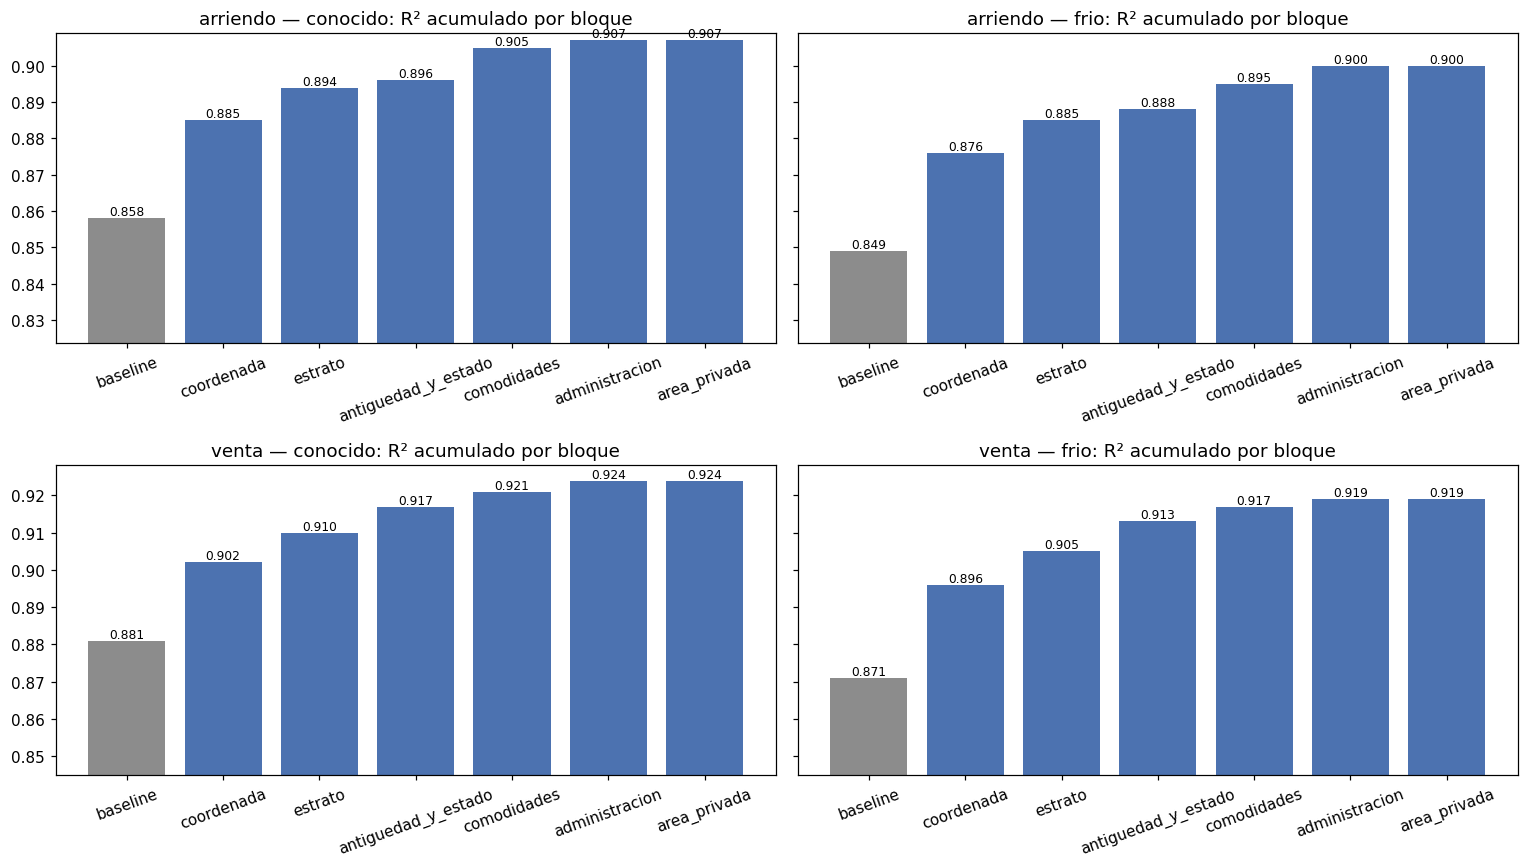

In [3]:
fig, ejes = plt.subplots(2, 2, figsize=(14, 8), sharey="row")
for fila, operacion in enumerate(OPERACIONES):
    for col, regimen in enumerate(("conocido", "frio")):
        eje = ejes[fila, col]
        sub = ablacion_b[(ablacion_b["operacion"] == operacion) & (ablacion_b["regimen"] == regimen)
                         & (ablacion_b["modo"] == "acumulado")]
        barras = eje.bar(sub["bloque"], sub["R2"],
                         color=["#8C8C8C"] + ["#4C72B0"] * (len(sub) - 1))
        eje.bar_label(barras, labels=[f"{r:.3f}" for r in sub["R2"]], fontsize=8)
        eje.set_title(f"{operacion} — {regimen}: R² acumulado por bloque")
        eje.set_ylim(sub["R2"].min() * .97, sub["R2"].max() * 1.01)
        eje.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


## B.2 Cara a cara: lo que trae el anuncio contra lo que traía el respaldo

Esta medición se hizo cuando las dos versiones convivían, sobre las filas que tenían ambas
(8.829 en arriendo, 6.884 en venta). Es la que decidió borrar el respaldo OSM/Esri; las
columnas ya no existen, así que queda la tabla. Delta de R² sobre una base que ya incluye el
otro bloque (para el estrato, la base tiene la coordenada; para la coordenada, el estrato):

| | versión | arriendo conocido | arriendo frío | venta conocido | venta frío |
|---|---|---|---|---|---|
| estrato | del anuncio | +0,007 | **+0,014** | +0,010 | **+0,013** |
| estrato | modal Esri | +0,003 | −0,002 | +0,005 | −0,003 |
| estrato | ambos | +0,009 | +0,014 | +0,011 | +0,013 |
| coordenada | del anuncio | +0,021 | **+0,026** | +0,016 | **+0,015** |
| coordenada | centroide OSM | +0,017 | +0,018 | +0,015 | +0,013 |
| coordenada | ambas | +0,023 | +0,023 | +0,018 | +0,016 |

Sumar el respaldo al dato del anuncio aporta **+0,002 como máximo**, y en arranque en frío el
estrato modal **resta**. Rescataba 72 coordenadas y 233 estratos de 44.836 filas (0,7 %) a
cambio de una o dos horas de red en cada máquina nueva. Se borró entero.


## B.3 Veredicto por bloque

Un bloque **se queda** si en algún régimen aporta al menos `UMBRAL_APORTE` (0,005 de R², el
mismo umbral de la Parte A) y no resta en arranque en frío. Lo que no pasa se borra del
pipeline, como se hizo con los POIs, la jerarquía administrativa y la criminalidad.


In [4]:
UMBRAL_APORTE = 0.005
BASE_EDA = {"arriendo": 0.833, "venta": 0.860}          # notebook 03, tarjeta sola
BASE_OSM = {"arriendo": 0.878, "venta": 0.904}          # Parte A, respaldo OSM/Esri

print("=== BLOQUES DEL DETALLE ===")
veredictos = {}
for bloque in BLOQUES_B:
    aislado = ablacion_b[(ablacion_b["modo"] == "aislado") & (ablacion_b["bloque"] == bloque)]
    acumulado = ablacion_b[(ablacion_b["modo"] == "acumulado") & (ablacion_b["bloque"] == bloque)]
    mejor = max(aislado["delta_R2"].max(), acumulado["delta_R2"].max())
    peor_frio = acumulado.loc[acumulado["regimen"] == "frio", "delta_R2"].min()
    veredictos[bloque] = mejor >= UMBRAL_APORTE and peor_frio > -UMBRAL_APORTE
    print(f"  {bloque:22} mejor aporte {mejor:+.3f} | peor acumulado en frío {peor_frio:+.3f} "
          f"-> {'SE QUEDA' if veredictos[bloque] else 'SE BORRA'}")

print("\n=== COMPUERTA (mejor R² en régimen conocido, todas las filas) ===")
for operacion in OPERACIONES:
    sub = ablacion_b[(ablacion_b["operacion"] == operacion) & (ablacion_b["regimen"] == "conocido")]
    print(f"  {operacion:9} baseline {sub.iloc[0]['R2']:.3f} -> mejor {sub['R2'].max():.3f} "
          f"| EDA (tarjeta): {BASE_EDA[operacion]:.3f} | Parte A (OSM): {BASE_OSM[operacion]:.3f}")


=== BLOQUES DEL DETALLE ===
  coordenada             mejor aporte +0.027 | peor acumulado en frío +0.025 -> SE QUEDA
  estrato                mejor aporte +0.024 | peor acumulado en frío +0.009 -> SE QUEDA
  antiguedad_y_estado    mejor aporte +0.011 | peor acumulado en frío +0.003 -> SE QUEDA
  comodidades            mejor aporte +0.020 | peor acumulado en frío +0.004 -> SE QUEDA
  administracion         mejor aporte +0.011 | peor acumulado en frío +0.002 -> SE QUEDA
  area_privada           mejor aporte +0.000 | peor acumulado en frío +0.000 -> SE BORRA

=== COMPUERTA (mejor R² en régimen conocido, todas las filas) ===
  arriendo  baseline 0.858 -> mejor 0.907 | EDA (tarjeta): 0.833 | Parte A (OSM): 0.878
  venta     baseline 0.881 -> mejor 0.924 | EDA (tarjeta): 0.860 | Parte A (OSM): 0.904


## B.4 Conclusiones de la Parte B

### Todo lo que trae el detalle aporta, menos el área privada

Acumulando bloque a bloque sobre todas las filas: arriendo pasa de **0,858 a 0,907** en el
régimen conocido y de **0,849 a 0,900** en frío; venta de **0,881 a 0,925** y de **0,871 a
0,920**. El MdAPE baja de 18 % a 14 %. La coordenada del anuncio es el bloque grande
(+0,022 a +0,028), el estrato el segundo (+0,018 a +0,024 aislado), y antigüedad,
comodidades y administración suman entre +0,003 y +0,011 cada uno. El área privada da
+0,000 porque el sitio nunca la llena (0 % de cobertura): **se borra del modelo**.

### La brecha de arranque en frío casi desaparece

En la Parte A el régimen frío quedaba entre 0,02 y 0,06 por debajo del conocido. Con la
coordenada y el estrato del propio inmueble la diferencia es de **0,005 a 0,007**: el
modelo ya no depende de haber visto el barrio, porque cada fila trae su ubicación.

### El respaldo OSM/Esri queda redundante

Sobre las 8.829 (arriendo) y 6.884 (venta) filas que tienen las dos versiones, sumar el
respaldo al dato del anuncio aporta **+0,002 como máximo**. Peor: en frío el estrato modal
solo resta (−0,002 / −0,003) donde el estrato del anuncio suma +0,014 / +0,013. Rescata 72
coordenadas y 233 estratos de 44.836 filas a cambio de una o dos horas de red en cada
máquina nueva. Por eso se borró entero de `src/enrich.py`: la etapa corre en segundos y sin
red, y la Parte A de este notebook quedó como historia en markdown.

### Compuerta

Arriendo **0,907** y venta **0,925** en régimen conocido, contra 0,878 / 0,904 del
enriquecimiento OSM y 0,833 / 0,860 del EDA. Pasa con margen. El modelo definitivo, con
búsqueda de hiperparámetros y cuantiles calibrados, está en `src/train.py` y sus
resultados en `05_modelo_y_sandbox.ipynb`.
